In [1]:
# Load pandas for dataframe operations.
import pandas as pd

In [2]:
# Read the cleaned recipes dataset from project root.
df = pd.read_csv('cleaned_recipes.csv')

In [3]:
# Inspect dataset schema and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157973 entries, 0 to 157972
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    157973 non-null  int64  
 1   Name                        157973 non-null  str    
 2   CookTime                    157973 non-null  str    
 3   PrepTime                    157973 non-null  str    
 4   TotalTime                   157973 non-null  str    
 5   Description                 157973 non-null  str    
 6   Images                      157973 non-null  str    
 7   RecipeCategory              157973 non-null  str    
 8   Keywords                    157973 non-null  str    
 9   RecipeIngredientQuantities  157973 non-null  str    
 10  RecipeIngredientParts       157973 non-null  str    
 11  Calories                    157973 non-null  float64
 12  FatContent                  157973 non-null  float64
 13  SaturatedFatContent      

In [4]:
# Preview the first rows for quick sanity check.
df.head()

,RecipeId,Name,CookTime,PrepTime,TotalTime,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,...,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeInstructions
0,1,Low-Fat Berry Blue Frozen Dessert,PT24H,PT45M,PT24H45M,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",Frozen Desserts,"c(""Dessert"", ""Low Protein"", ""Low Cholesterol"",...","c(""4"", ""1/4"", ""1"", ""1"")",...,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,2,Biryani,PT25M,PT4H,PT4H25M,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",Chicken Breast,"c(""Chicken Thigh & Leg"", ""Chicken"", ""Poultry"",...","c(""1"", ""4"", ""2"", ""2"", ""8"", ""1/4"", ""8"", ""1/2"", ...",...,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,"c(""Soak saffron in warm milk for 5 minutes and..."
2,3,Best Lemonade,PT5M,PT30M,PT35M,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",Beverages,"c(""Low Protein"", ""Low Cholesterol"", ""Healthy"",...","c(""1 1/2"", ""1"", NA, ""1 1/2"", NA, ""3/4"")",...,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,4,Carina's Tofu-Vegetable Kebabs,PT20M,PT24H,PT24H20M,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",Soy/Tofu,"c(""Beans"", ""Vegetable"", ""Low Cholesterol"", ""We...","c(""12"", ""1"", ""2"", ""1"", ""10"", ""1"", ""3"", ""2"", ""2...",...,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,"c(""Drain the tofu, carefully squeezing out exc..."
4,5,Cabbage Soup,PT30M,PT20M,PT50M,Make and share this Cabbage Soup recipe from F...,"c(""https://img.sndimg.com/food/image/upload/w_...",Vegetable,"c(""Low Protein"", ""Vegan"", ""Low Cholesterol"", ""...","c(""46"", ""4"", ""1"", ""2"", ""1"")",...,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,"c(""Mix everything together and bring to a boil..."


In [5]:
# Import dependencies and configure GPU-aware runtime flags.
import importlib
import subprocess
import sys
import os

required_pkgs = [
    "torch",
    "transformers",
    "accelerate",
    "sentencepiece",
    "isodate",
    "scikit-learn",
]

missing = []
for pkg in required_pkgs:
    module_name = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(pkg)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import ast
import csv
import re
from io import StringIO
from typing import List

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, DataCollatorForSeq2Seq, Trainer, TrainingArguments, T5ForConditionalGeneration
import isodate

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- GPU optimization setup ----
USE_CUDA = torch.cuda.is_available()
PIN_MEMORY = USE_CUDA
NUM_WORKERS = min(4, max(1, (os.cpu_count() or 2) // 2))
USE_BF16 = bool(USE_CUDA and torch.cuda.is_bf16_supported())
USE_FP16 = bool(USE_CUDA and not USE_BF16)

if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    gpu_name = torch.cuda.get_device_name(0)
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"CUDA enabled: {gpu_name} ({total_gb:.1f} GB)")
    print(f"AMP mode -> bf16={USE_BF16}, fp16={USE_FP16}")
else:
    print("CUDA not available; running on CPU.")

c:\SEM-6\DL\Naan_binary\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA enabled: NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
AMP mode -> bf16=True, fp16=False


In [6]:
# Parse and normalize recipe fields, then build model input/target text.
NUTRITION_COLS = [
    "Calories",
    "FatContent",
    "SaturatedFatContent",
    "CholesterolContent",
    "SodiumContent",
    "CarbohydrateContent",
    "FiberContent",
    "SugarContent",
    "ProteinContent",
]

UNIT_WORDS = {
    "tsp", "teaspoon", "teaspoons", "tbsp", "tablespoon", "tablespoons",
    "cup", "cups", "oz", "ounce", "ounces", "lb", "lbs", "pound", "pounds",
    "g", "gram", "grams", "kg", "ml", "l", "liter", "liters", "pinch", "dash",
    "clove", "cloves", "slice", "slices", "can", "cans", "package", "packages"
}

def parse_list_like(value) -> List[str]:
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []

    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception:
            pass

    if text.startswith("c(") and text.endswith(")"):
        inner = text[2:-1].strip()
        reader = csv.reader(StringIO(inner), delimiter=",", quotechar='"', skipinitialspace=True)
        row = next(reader, [])
        out = []
        for token in row:
            token = token.strip().replace('""', '"')
            if token in {"", "NA", "None", "nan"}:
                continue
            out.append(token)
        return out

    return [text]


def parse_iso_minutes(value) -> float:
    if pd.isna(value):
        return 0.0
    text = str(value).strip()
    if not text:
        return 0.0
    try:
        duration = isodate.parse_duration(text)
        if hasattr(duration, "total_seconds"):
            return float(duration.total_seconds() / 60.0)
    except Exception:
        pass

    m = re.match(r"P(?:(\d+)D)?(?:T(?:(\d+)H)?(?:(\d+)M)?)?", text)
    if not m:
        return 0.0
    days = int(m.group(1) or 0)
    hours = int(m.group(2) or 0)
    minutes = int(m.group(3) or 0)
    return float(days * 24 * 60 + hours * 60 + minutes)


def normalize_ingredient(token: str) -> str:
    s = token.lower().strip()
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"^\s*(?:\d+\s+\d+/\d+|\d+/\d+|\d+(?:\.\d+)?)\s*", "", s)
    s = re.sub(r"^\s*(?:x|about|approx\.?|approximately)\s+", "", s)

    parts = s.split()
    while parts and re.fullmatch(r"\d+(?:\.\d+)?", parts[0]):
        parts.pop(0)
    while parts and parts[0] in UNIT_WORDS:
        parts.pop(0)

    s = " ".join(parts)
    s = re.sub(r"[^a-zA-Z\s-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip(" -")
    return s


def build_input_prompt(ingredients: List[str], total_minutes: float) -> str:
    cleaned = [normalize_ingredient(x) for x in ingredients]
    cleaned = [x for x in cleaned if x]
    cleaned = list(dict.fromkeys(cleaned))
    if len(cleaned) > 40:
        cleaned = cleaned[:40]
    prompt = f"ingredients: {', '.join(cleaned)}"
    if total_minutes > 0:
        prompt += f" | ready_in_min: {int(total_minutes)}"
    return prompt


def build_target_text(name: str, instructions: List[str]) -> str:
    steps = [s.strip() for s in instructions if s and s.strip()]
    if len(steps) > 25:
        steps = steps[:25]
    body = "\n".join(f"{i+1}. {step}" for i, step in enumerate(steps))
    title = str(name).strip() if pd.notna(name) else "Unknown Recipe"
    return f"name: {title}\nsteps:\n{body}"

df_work = df.copy()
df_work["_ingredient_list"] = df_work["RecipeIngredientParts"].apply(parse_list_like)
df_work["_instruction_list"] = df_work["RecipeInstructions"].apply(parse_list_like)
df_work["_total_minutes"] = df_work["TotalTime"].apply(parse_iso_minutes)

df_work["RecipeServings"] = pd.to_numeric(df_work["RecipeServings"], errors="coerce")
serving_median = df_work["RecipeServings"].dropna().median()
if pd.isna(serving_median) or serving_median <= 0:
    serving_median = 4.0
df_work["RecipeServings"] = df_work["RecipeServings"].fillna(serving_median)
df_work["RecipeServings"] = df_work["RecipeServings"].clip(lower=1.0)

for col in NUTRITION_COLS:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce")
    df_work[col] = df_work[col] / df_work["RecipeServings"]

df_work["input_text"] = df_work.apply(
    lambda r: build_input_prompt(r["_ingredient_list"], r["_total_minutes"]),
    axis=1,
)
df_work["target_text"] = df_work.apply(
    lambda r: build_target_text(r["Name"], r["_instruction_list"]),
    axis=1,
)

df_work = df_work[df_work["input_text"].str.len() > 15]
df_work = df_work[df_work["target_text"].str.len() > 20]
df_work = df_work.dropna(subset=NUTRITION_COLS).reset_index(drop=True)

print("Prepared rows:", len(df_work))
print(df_work[["input_text", "target_text"]].head(2))

Prepared rows: 157973
                                          input_text  \
0  ingredients: blueberries, granulated sugar, va...   
1  ingredients: saffron, milk, hot green chili pe...   

                                         target_text  
0  name: Low-Fat Berry Blue Frozen Dessert\nsteps...  
1  name: Biryani\nsteps:\n1. Soak saffron in warm...  


In [7]:
# Cell 7
# Split data, transform targets, and build tokenized datasets/collator.
# Use all prepared rows for training unless you intentionally cap this value.
MAX_ROWS = len(df_work)
if len(df_work) > MAX_ROWS:
    df_model = df_work.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)
else:
    df_model = df_work.copy()

idx = np.arange(len(df_model))
train_idx, val_idx = train_test_split(idx, test_size=0.1, random_state=SEED)

train_df = df_model.iloc[train_idx].reset_index(drop=True)
val_df = df_model.iloc[val_idx].reset_index(drop=True)

# Heavy-tailed targets are stabilized with log1p before standard scaling.
LOG_TARGET_COLS = {"Calories", "SodiumContent", "CholesterolContent"}

def _transform_target_frame(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame[NUTRITION_COLS].astype(np.float32).copy()
    for col in LOG_TARGET_COLS:
        out[col] = np.log1p(np.clip(out[col].to_numpy(dtype=np.float32), a_min=0.0, a_max=None))
    return out

def inverse_targets(y_scaled: np.ndarray) -> np.ndarray:
    y_t = scaler.inverse_transform(y_scaled)
    y_t = np.asarray(y_t, dtype=np.float32).copy()
    for i, col in enumerate(NUTRITION_COLS):
        if col in LOG_TARGET_COLS:
            y_t[:, i] = np.expm1(y_t[:, i])
    return np.clip(y_t, a_min=0.0, a_max=None)

scaler = StandardScaler()
train_target_frame = _transform_target_frame(train_df)
val_target_frame = _transform_target_frame(val_df)
train_targets = scaler.fit_transform(train_target_frame.to_numpy(dtype=np.float32)).astype(np.float32)
val_targets = scaler.transform(val_target_frame.to_numpy(dtype=np.float32)).astype(np.float32)

# Safety guard: replace any non-finite scaled targets to avoid NaN regression loss.
train_targets = np.nan_to_num(train_targets, nan=0.0, posinf=0.0, neginf=0.0)
val_targets = np.nan_to_num(val_targets, nan=0.0, posinf=0.0, neginf=0.0)

# Per-target weights from pre-scaling spread (so weighting is meaningful).
raw_std = train_target_frame.std(axis=0).to_numpy(dtype=np.float32) + 1e-6
target_weights_np = 1.0 / raw_std
target_weights_np = (target_weights_np / target_weights_np.mean()).astype(np.float32)
TARGET_WEIGHTS_T = torch.tensor(target_weights_np, dtype=torch.float32)

MODEL_NAME = "google/flan-t5-small"
MAX_INPUT_LEN = 128
MAX_TARGET_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class RecipeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, y_scaled: np.ndarray):
        self.frame = frame
        self.y = y_scaled

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        model_in = tokenizer(
            row["input_text"],
            truncation=True,
            max_length=MAX_INPUT_LEN,
        )
        model_out = tokenizer(
            text_target=row["target_text"],
            truncation=True,
            max_length=MAX_TARGET_LEN,
        )

        return {
            "input_ids": model_in["input_ids"],
            "attention_mask": model_in["attention_mask"],
            "labels": model_out["input_ids"],
            "reg_targets": torch.tensor(self.y[idx], dtype=torch.float32),
        }

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=MODEL_NAME, padding=True)

def multitask_collate(features):
    reg_targets = torch.stack([f["reg_targets"] for f in features])
    core = [{k: v for k, v in f.items() if k != "reg_targets"} for f in features]
    batch = data_collator(core)
    batch["labels"][batch["labels"] == tokenizer.pad_token_id] = -100

    if not torch.isfinite(reg_targets).all():
        raise ValueError("Found non-finite values in reg_targets.")
    if (batch["labels"] != -100).sum().item() == 0:
        raise ValueError("All labels are -100 in this batch; check target tokenization.")

    batch["reg_targets"] = reg_targets
    return batch

train_ds = RecipeDataset(train_df, train_targets)
val_ds = RecipeDataset(val_df, val_targets)

print(f"Model rows: {len(df_model)} | Train size: {len(train_ds)} | Val size: {len(val_ds)}")
print("train_targets finite:", np.isfinite(train_targets).all(), "| val_targets finite:", np.isfinite(val_targets).all())
print("Target weights:", {k: float(v) for k, v in zip(NUTRITION_COLS, target_weights_np)})

Model rows: 157973 | Train size: 142175 | Val size: 15798
train_targets finite: True | val_targets finite: True
Target weights: {'Calories': 2.5340518951416016, 'FatContent': 0.2308514565229416, 'SaturatedFatContent': 0.5051708817481995, 'CholesterolContent': 2.039935827255249, 'SodiumContent': 1.8586242198944092, 'CarbohydrateContent': 0.10364596545696259, 'FiberContent': 1.2439724206924438, 'SugarContent': 0.15652582049369812, 'ProteinContent': 0.32722166180610657}


In [8]:
# Cell 8
# Define multitask FLAN-T5 model with weighted regression head.
class MultiTaskFlanT5(nn.Module):
    def __init__(self, model_name: str, num_targets: int, reg_weight: float = 0.5, target_weights: torch.Tensor = None):
        super().__init__()
        self.backbone = T5ForConditionalGeneration.from_pretrained(model_name)
        hidden = self.backbone.config.d_model

        self.reg_head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden, num_targets),
        )
        self.reg_weight = reg_weight

        if target_weights is None:
            target_weights = torch.ones(num_targets, dtype=torch.float32)
        self.register_buffer("target_weights", target_weights.float())

    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        # Pass through to HF backbone so Trainer can enable checkpointing.
        if hasattr(self.backbone, "gradient_checkpointing_enable"):
            if gradient_checkpointing_kwargs is None:
                self.backbone.gradient_checkpointing_enable()
            else:
                self.backbone.gradient_checkpointing_enable(
                    gradient_checkpointing_kwargs=gradient_checkpointing_kwargs
                )

    def gradient_checkpointing_disable(self):
        if hasattr(self.backbone, "gradient_checkpointing_disable"):
            self.backbone.gradient_checkpointing_disable()

    def forward(self, input_ids=None, attention_mask=None, labels=None, reg_targets=None, **kwargs):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            return_dict=True,
        )

        enc_hidden = out.encoder_last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        reg_pred = self.reg_head(pooled)

        ce_loss = out.loss if out.loss is not None else torch.tensor(0.0, device=input_ids.device)
        reg_loss = torch.tensor(0.0, device=input_ids.device)
        if reg_targets is not None:
            # Using SmoothL1 (Huber) loss for better stability with numbers
            criterion = nn.SmoothL1Loss(reduction='none')
            loss_val = criterion(reg_pred, reg_targets)
            
            # Apply your target weights (Calories, Sodium, etc.)
            w = self.target_weights.view(1, -1).to(loss_val.device)
            reg_loss = (loss_val * w).mean()

        total_loss = ce_loss + (self.reg_weight * reg_loss)

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite loss detected: total={total_loss.item()}, ce={ce_loss.item()}, reg={reg_loss.item()}"
            )

        return {
            "loss": total_loss,
            "logits": out.logits,
            "regression_logits": reg_pred,
            "ce_loss": ce_loss.detach(),
            "reg_loss": reg_loss.detach(),
        }

    @torch.no_grad()
    def generate_text(self, input_ids, attention_mask, **kwargs):
        return self.backbone.generate(input_ids=input_ids, attention_mask=attention_mask, **kwargs)

In [9]:
# Cell 9
# Run a small forward-pass sanity check before full training.
model = MultiTaskFlanT5(
    MODEL_NAME,
    num_targets=len(NUTRITION_COLS),
    reg_weight=0.5,
    target_weights=TARGET_WEIGHTS_T,
 )
device = torch.device("cuda" if USE_CUDA else "cpu")
model.to(device)
batch = multitask_collate([train_ds[i] for i in range(min(4, len(train_ds)))])
batch = {k: v.to(device) for k, v in batch.items()}
amp_dtype = torch.bfloat16 if USE_BF16 else torch.float16
with torch.no_grad():
    if USE_CUDA:
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
                reg_targets=batch["reg_targets"],
            )
    else:
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
            reg_targets=batch["reg_targets"],
        )
print("Sanity loss:", float(out["loss"]))
print("CE loss:", float(out["ce_loss"]), "| REG loss:", float(out["reg_loss"]))

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 4288.91it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Sanity loss: 3.3701224327087402
CE loss: 3.242170572280884 | REG loss: 0.255903959274292


In [10]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from transformers import TrainerCallback

class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.train_losses = []
        self.reg_losses = []
        self.ce_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if 'loss' in logs:
            self.steps.append(state.global_step)
            self.train_losses.append(logs['loss'])
            
            # Extract internal losses if your model returns them
            # Note: Trainer logs only what is in 'logs' dictionary
            # To get specific sub-losses, you'd need to include them in the Trainer's log_metrics
            
            clear_output(wait=True)
            plt.figure(figsize=(10, 5))
            plt.plot(self.steps, self.train_losses, label='Total Loss', color='purple')
            plt.title(f"Training Progress (Step {state.global_step})")
            plt.xlabel("Steps")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True)
            plt.show()

plot_callback = LivePlotCallback()

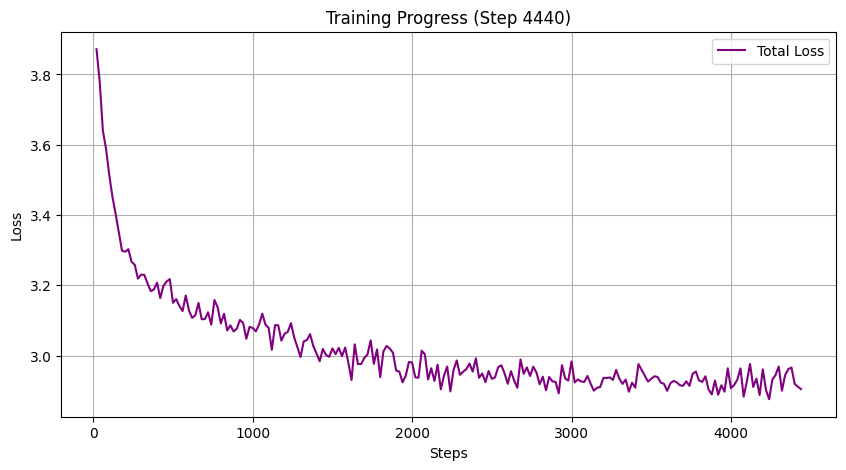

{'train_runtime': 2549.739, 'train_samples_per_second': 55.761, 'train_steps_per_second': 1.743, 'total_flos': 0.0, 'train_loss': 3.0187306108974856, 'epoch': 1.0}


In [11]:
# Cell 10
# Configure and run training with evaluation and best-checkpoint callback.
import os
import inspect
from transformers import TrainerCallback

# Main run: longer training and stronger regression signal.
# REG_WEIGHT = 1.0  # increase to prioritize regression loss more (e.g., 1.0 means equal weight to CE and REG)
# TARGET_EFFECTIVE_EPOCHS = 1.0  # 1.0 ~= one full pass over train split
# RUN_TRAINING_NOW = True  # set True to start training immediately

# --- Configuration ---
RUN_TRAINING_NOW = True
RUN_REG_WEIGHT_SWEEP = False # Keep this False!
REG_WEIGHT = 1.0 # Increased for better nutrition accuracy

# --- Model Initialization ---
model = MultiTaskFlanT5(
    MODEL_NAME,
    num_targets=len(NUTRITION_COLS),
    reg_weight=REG_WEIGHT,
    target_weights=TARGET_WEIGHTS_T,
)
model.to(device)
model.backbone.config.tie_word_embeddings = False # Silence the warning

model = MultiTaskFlanT5(
    MODEL_NAME,
    num_targets=len(NUTRITION_COLS),
    reg_weight=REG_WEIGHT,
    target_weights=TARGET_WEIGHTS_T,
)

class BestEvalLossSaver(TrainerCallback):
    def __init__(self, save_dir: str):
        self.save_dir = save_dir
        self.best = float("inf")
        os.makedirs(self.save_dir, exist_ok=True)

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if metrics is None or "eval_loss" not in metrics or model is None:
            return control
        current = float(metrics["eval_loss"])
        if current < self.best:
            self.best = current
            save_path = os.path.join(self.save_dir, "best_eval_loss_model.pt")
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "reg_weight": REG_WEIGHT,
                    "target_weights": TARGET_WEIGHTS_T.cpu().numpy(),
                    "scaler_mean": scaler.mean_,
                    "scaler_scale": scaler.scale_,
                    "nutrition_cols": NUTRITION_COLS,
                    "log_target_cols": list(LOG_TARGET_COLS),
                    "step": state.global_step,
                    "best_eval_loss": self.best,
                },
                save_path,
            )
            print(f"Saved new best model at step {state.global_step} with eval_loss={self.best:.6f}")
        return control

supports_gc = hasattr(model, "gradient_checkpointing_enable")
args_dict = {
    "output_dir": "./recipe_multitask_ckpt",
    "learning_rate": 2e-5,
    "lr_scheduler_type": "cosine",
    "warmup_steps": 100,
    "per_device_train_batch_size": 32, 
    "per_device_eval_batch_size": 8,
    "gradient_accumulation_steps": 1,
    "num_train_epochs": 1,
    "weight_decay": 0.01,
    "eval_strategy": "no",
    "eval_steps": 300,
    "save_strategy": "no",
    "logging_steps": 20,
    "report_to": "none",
    "fp16": False,
    "bf16": USE_BF16,
    "max_grad_norm": 1.0,
    "remove_unused_columns": False,
    "load_best_model_at_end": False,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "dataloader_num_workers": 0,
    "dataloader_pin_memory": PIN_MEMORY,
    "eval_accumulation_steps": 4,
    "gradient_checkpointing": supports_gc,
    "group_by_length": True,
    "torch_empty_cache_steps": 200,
}

supported = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
filtered_args = {k: v for k, v in args_dict.items() if k in supported}
dropped = sorted(set(args_dict.keys()) - set(filtered_args.keys()))
if dropped:
    print("Dropped unsupported TrainingArguments:", dropped)
if not supports_gc and "gradient_checkpointing" in filtered_args:
    print("Model does not expose gradient checkpointing; disabling it.")

training_args = TrainingArguments(**{k: v for k, v in args_dict.items() if k in supported})

best_saver = BestEvalLossSaver(save_dir=training_args.output_dir)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=multitask_collate,
    callbacks=[best_saver,plot_callback],
)

if RUN_TRAINING_NOW:
    print("Starting training...")
    train_result = trainer.train()
    print(train_result.metrics)
else:
    print("Trainer configured. Set RUN_TRAINING_NOW=True and rerun this cell to start training.")

# Optional short sweep for regression weight tuning (disabled by default).
RUN_REG_WEIGHT_SWEEP = False
REG_WEIGHT_CANDIDATES = [0.5, 1.0]
SWEEP_MAX_STEPS = 120

if RUN_REG_WEIGHT_SWEEP:
    sweep_rows = []
    for rw in REG_WEIGHT_CANDIDATES:
        print(f"\n--- Sweep run reg_weight={rw} ---")
        sweep_model = MultiTaskFlanT5(
            MODEL_NAME,
            num_targets=len(NUTRITION_COLS),
            reg_weight=rw,
            target_weights=TARGET_WEIGHTS_T,
        )
        sweep_args_dict = {
            "output_dir": f"./recipe_multitask_ckpt/sweep_rw_{str(rw).replace('.', '_')}",
            "learning_rate": 2e-5,
            "per_device_train_batch_size": 8,
            "per_device_eval_batch_size": 8,
            "gradient_accumulation_steps": 2,
            "max_steps": SWEEP_MAX_STEPS,
            "eval_strategy": "steps",
            "eval_steps": 60,
            "save_strategy": "no",
            "logging_steps": 30,
            "report_to": "none",
            "fp16": USE_FP16,
            "bf16": USE_BF16,
            "remove_unused_columns": False,
            "dataloader_num_workers": NUM_WORKERS,
            "dataloader_pin_memory": PIN_MEMORY,
            "gradient_checkpointing": hasattr(sweep_model, "gradient_checkpointing_enable"),
        }
        sweep_filtered = {k: v for k, v in sweep_args_dict.items() if k in supported}
        sweep_args = TrainingArguments(**sweep_filtered)
        sweep_trainer = Trainer(
            model=sweep_model,
            args=sweep_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            data_collator=multitask_collate,
        )
        sweep_trainer.train()
        ev = sweep_trainer.evaluate()
        sweep_rows.append({"reg_weight": rw, "eval_loss": float(ev.get("eval_loss", np.nan))})

    sweep_df = pd.DataFrame(sweep_rows).sort_values("eval_loss")
    display(sweep_df)

In [12]:
# Cell 11
# Define recipe quality scoring and candidate reranking utilities.
ACTION_VERBS = {
    "add", "mix", "stir", "heat", "cook", "bake", "boil", "simmer", "saute", "fry",
    "chop", "slice", "season", "serve", "preheat", "whisk", "knead", "rest", "marinate"
}

def _extract_input_ingredients_from_prompt(input_text: str):
    head = input_text.split("|", 1)[0].replace("ingredients:", "").strip()
    parts = [p.strip() for p in head.split(",") if p.strip()]
    return [normalize_ingredient(p) for p in parts if normalize_ingredient(p)]

def parse_generated_recipe_text(text: str):
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return "", []

    title = ""
    m_title = re.search(r"name\s*:\s*(.*?)(?=\s+steps\s*:|$)", text, flags=re.IGNORECASE)
    if m_title:
        title = m_title.group(1).strip()

    body = re.sub(r"^.*?steps\s*:\s*", "", text, flags=re.IGNORECASE)
    parts = re.split(r"\s(?=\d+[\).]\s)", body)
    steps = []
    for p in parts:
        p = p.strip()
        if re.match(r"^\d+[\).]\s+", p):
            steps.append(re.sub(r"^\d+[\).]\s+", "", p).strip())

    if not steps:
        lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
        for ln in lines:
            if re.match(r"^\d+[\).]\s+", ln):
                steps.append(re.sub(r"^\d+[\).]\s+", "", ln).strip())
        if not steps and len(lines) >= 3:
            steps = lines[:10]

    if not title:
        title = "Generated Recipe"
    return title, steps

def score_recipe_validity(generated_text: str, input_text: str):
    title, steps = parse_generated_recipe_text(generated_text)
    src_ings = set(_extract_input_ingredients_from_prompt(input_text))

    penalties = []
    score = 100.0

    if len(title.strip()) < 3:
        score -= 10
        penalties.append("missing_or_weak_title")

    if len(steps) < 3:
        score -= 35
        penalties.append("too_few_steps")

    if steps:
        short_steps = sum(1 for s in steps if len(s.split()) < 4)
        if short_steps > 0:
            score -= min(20, short_steps * 5)
            penalties.append("very_short_steps")

        first_words = [s.split()[0].lower() for s in steps if s.split()]
        verb_hits = sum(1 for w in first_words if w in ACTION_VERBS)
        verb_ratio = verb_hits / max(1, len(steps))
        if verb_ratio < 0.3:
            score -= 15
            penalties.append("low_actionability")

        uniq_ratio = len(set(s.lower() for s in steps)) / max(1, len(steps))
        if uniq_ratio < 0.8:
            score -= 15
            penalties.append("repetitive_steps")

        # Penalize obvious duplicated phrase patterns like "bay leaves and bay leaves".
        full_text = " ".join(steps).lower()
        if re.search(r"\b([a-z]+(?:\s+[a-z]+){0,2})\s+and\s+\1\b", full_text):
            score -= 20
            penalties.append("duplicated_phrase")

        # Penalize repeated ingredient mention beyond a soft threshold.
        if src_ings:
            repeated_ing = 0
            for ing in src_ings:
                toks = [t for t in ing.split() if len(t) > 2]
                if toks:
                    hits = sum(full_text.count(t) for t in toks)
                    if hits >= 4:
                        repeated_ing += 1
            if repeated_ing > 0:
                score -= min(20, repeated_ing * 6)
                penalties.append("over_repeated_ingredients")

    step_text = " ".join(steps).lower()
    if src_ings:
        covered = 0
        for ing in src_ings:
            toks = [t for t in ing.split() if len(t) > 2]
            if any(t in step_text for t in toks):
                covered += 1
        coverage = covered / max(1, len(src_ings))
        if coverage < 0.35:
            score -= 25
            penalties.append("low_ingredient_alignment")
    else:
        coverage = np.nan

    unsafe_markers = ["raw chicken", "undercooked", "poison", "burn until black"]
    if any(m in generated_text.lower() for m in unsafe_markers):
        score -= 40
        penalties.append("unsafe_marker")

    return {
        "title": title,
        "steps": steps,
        "score": float(max(0.0, min(100.0, score))),
        "ingredient_coverage": float(coverage) if coverage == coverage else np.nan,
        "penalties": penalties,
    }

@torch.no_grad()
def generate_best_recipe(input_text: str, num_candidates: int = 5):
    device = next(model.parameters()).device
    enc = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN)
    enc = {k: v.to(device) for k, v in enc.items()}

    gen_ids = model.generate_text(
        enc["input_ids"],
        enc["attention_mask"],
        max_length=MAX_TARGET_LEN,
        num_beams=max(6, num_candidates),
        num_return_sequences=num_candidates,
        do_sample=False,
        no_repeat_ngram_size=3,
        repetition_penalty=1.15,
        length_penalty=0.95,
        early_stopping=True,
    )

    texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
    scored = []
    for t in texts:
        info = score_recipe_validity(t, input_text)
        scored.append({"text": t, **info})

    scored = sorted(scored, key=lambda x: x["score"], reverse=True)
    return scored[0], scored

In [22]:
# Cell 12
# Generate recipe and blended nutrition prediction for one sample.
inv_scale = inverse_targets

sample = val_df.iloc[0]
input_text = sample["input_text"]

device = torch.device("cuda" if USE_CUDA else "cpu")
model.to(device)
model.eval()
amp_dtype = torch.bfloat16 if USE_BF16 else torch.float16

best_recipe, all_candidates = generate_best_recipe(input_text, num_candidates=5)
pred_recipe = best_recipe["text"]

# Nutrition from multitask head
enc = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN)
enc = {k: v.to(device) for k, v in enc.items()}
with torch.no_grad():
    if USE_CUDA:
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            enc_hidden = model.backbone.encoder(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                return_dict=True,
            ).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
            pred_scaled_mt = model.reg_head(pooled).float().cpu().numpy()
    else:
        enc_hidden = model.backbone.encoder(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            return_dict=True,
        ).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        pred_scaled_mt = model.reg_head(pooled).float().cpu().numpy()
pred_nutrition_mt = inv_scale(pred_scaled_mt)[0]

# Nutrition from dedicated regressor (optional; available after Cell 14 runs).
regressor_ready = all(name in globals() for name in ["tfidf", "xnum_scaler", "nutrition_model", "sparse"])
if regressor_ready:
    x_text = tfidf.transform([input_text])
    x_num = xnum_scaler.transform(sample[["RecipeServings", "_total_minutes"]].to_numpy(dtype=np.float32).reshape(1, -1))
    x_all = sparse.hstack([x_text, sparse.csr_matrix(x_num)], format="csr")
    pred_nutrition_reg = nutrition_model.predict(x_all).astype(np.float32)[0]
    pred_nutrition_reg = np.clip(pred_nutrition_reg, a_min=0.0, a_max=None)

    # Blend predictions for stability (can tune).
    blend_alpha = 0.2  # weight for multitask head
    pred_nutrition = (blend_alpha * pred_nutrition_mt) + ((1.0 - blend_alpha) * pred_nutrition_reg)
    pred_mode = "blended (multitask + regressor)"
else:
    pred_nutrition = pred_nutrition_mt
    pred_mode = "multitask-only (run Cell 14 to enable blending)"

print("Input:")
print(input_text)
print("\nBest generated recipe (reranked by validity):")
print(pred_recipe)
print("\nRecipe validity score:", round(best_recipe["score"], 2))
print("Ingredient coverage:", round(float(best_recipe["ingredient_coverage"]), 3))
print("Penalties:", best_recipe["penalties"] if best_recipe["penalties"] else "None")

print("\nTop candidate scores:")
for i, c in enumerate(all_candidates[:3], start=1):
    print(f"{i}. score={c['score']:.2f}, penalties={c['penalties']}")

print(f"\nPredicted nutrition (per serving) [{pred_mode}]:")
for c, v in zip(NUTRITION_COLS, pred_nutrition):
    print(f"{c}: {v:.2f}")

print("\nGround truth nutrition (per serving):")
print(sample[NUTRITION_COLS].to_string())

Input:
ingredients: salt, fresh black pepper, paprika, curry powder, cayenne pepper, oregano, bay leaves, thyme, garlic powder, olive oil | ready_in_min: 65

Best generated recipe (reranked by validity):
name: Thai Curry steps: 1. Preheat oven to 350°F. 2. In a large bowl, combine the salt, pepper, paprika, curry powder, cayenne pepper, oregano, bay leaves, thyme, garlic powder and olive oil. 3. Add the bay leaves and bay leaves to the bowl and mix well. 4. Add the curry powder and saute for about 5 minutes. 5. Stir in the sauteed bay leaves. 6. Add the marinade and cook for about 10 minutes. 7. Remove from the heat and stir in the remaining marinade.

Recipe validity score: 62.0
Ingredient coverage: 1.0
Penalties: ['duplicated_phrase', 'over_repeated_ingredients']

Top candidate scores:
1. score=62.00, penalties=['duplicated_phrase', 'over_repeated_ingredients']
2. score=62.00, penalties=['duplicated_phrase', 'over_repeated_ingredients']
3. score=57.00, penalties=['very_short_steps', 

In [14]:
# Cell 13
# Evaluate nutrition regression metrics on full validation split.
from torch.utils.data import DataLoader

if "metrics_df" in globals() and "baseline_metrics_df" not in globals():
    baseline_metrics_df = metrics_df.copy()
    baseline_overall_mae = float(overall_mae) if "overall_mae" in globals() else np.nan
    baseline_overall_rmse = float(overall_rmse) if "overall_rmse" in globals() else np.nan

device = torch.device("cuda" if USE_CUDA else "cpu")
model.to(device)
model.eval()

val_loader = DataLoader(
    val_ds,
    batch_size=64, # increased batch size for faster evaluation
    shuffle=False,
    collate_fn=multitask_collate,
    num_workers=0,
    pin_memory=True,
)

pred_scaled_all = []
true_scaled_all = []
amp_dtype = torch.bfloat16 if USE_BF16 else torch.float16

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        reg_targets = batch["reg_targets"].to(device, non_blocking=True)

        if USE_CUDA:
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                enc_hidden = model.backbone.encoder(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    return_dict=True,
                ).last_hidden_state
                mask = attention_mask.unsqueeze(-1).float()
                pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
                reg_pred = model.reg_head(pooled)
        else:
            enc_hidden = model.backbone.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True,
            ).last_hidden_state
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (enc_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
            reg_pred = model.reg_head(pooled)

        pred_scaled_all.append(reg_pred.detach().float().cpu().numpy())
        true_scaled_all.append(reg_targets.detach().float().cpu().numpy())

pred_scaled_all = np.concatenate(pred_scaled_all, axis=0)
true_scaled_all = np.concatenate(true_scaled_all, axis=0)

pred_unscaled = inverse_targets(pred_scaled_all)
true_unscaled = inverse_targets(true_scaled_all)

rows = []
eps = 1e-6
for i, col in enumerate(NUTRITION_COLS):
    err = pred_unscaled[:, i] - true_unscaled[:, i]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))

    denom = np.abs(true_unscaled[:, i])
    valid = denom > 1.0
    mape = float(np.mean(np.abs(err[valid]) / denom[valid]) * 100.0) if np.any(valid) else np.nan
    smape = float(np.mean(2.0 * np.abs(err) / (np.abs(pred_unscaled[:, i]) + np.abs(true_unscaled[:, i]) + eps)) * 100.0)

    y_true = true_unscaled[:, i]
    y_pred = pred_unscaled[:, i]
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2) + eps)
    r2 = 1.0 - (ss_res / ss_tot)

    rows.append({
        "nutrient": col,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%_(|y|>1)": mape,
        "sMAPE_%": smape,
        "R2": r2,
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values("MAE"))

overall_mae = float(np.mean(np.abs(pred_unscaled - true_unscaled)))
overall_rmse = float(np.sqrt(np.mean((pred_unscaled - true_unscaled) ** 2)))
print(f"Overall MAE: {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

if "baseline_metrics_df" in globals():
    comp = metrics_df[["nutrient", "MAE", "RMSE"]].merge(
        baseline_metrics_df[["nutrient", "MAE", "RMSE"]],
        on="nutrient",
        suffixes=("_new", "_baseline"),
    )
    comp["MAE_delta"] = comp["MAE_new"] - comp["MAE_baseline"]
    comp["RMSE_delta"] = comp["RMSE_new"] - comp["RMSE_baseline"]
    print("\nComparison vs baseline (negative delta is better):")
    display(comp.sort_values("MAE_delta"))
    if "baseline_overall_mae" in globals() and "baseline_overall_rmse" in globals():
        print(f"Baseline overall MAE/RMSE: {baseline_overall_mae:.4f} / {baseline_overall_rmse:.4f}")
        print(f"Current  overall MAE/RMSE: {overall_mae:.4f} / {overall_rmse:.4f}")

,nutrient,MAE,RMSE,MAPE_%_(|y|>1),sMAPE_%,R2
6,FiberContent,0.720639,2.135819,57.964581,93.909142,0.012889
2,SaturatedFatContent,1.669698,5.710963,46.620468,99.162468,0.018169
8,ProteinContent,3.087120,9.004291,72.181740,95.250992,0.050440
7,SugarContent,4.198371,17.702345,78.005447,102.433685,0.018146
1,FatContent,4.220412,15.462820,83.036461,93.475327,0.006133
5,CarbohydrateContent,8.736956,29.404041,127.962708,87.382195,-0.000243
3,CholesterolContent,14.697507,51.165031,111.662842,104.892090,0.046588
0,Calories,72.342987,254.000565,150.156357,73.044495,-0.031011
4,SodiumContent,120.060417,519.734436,202.256149,88.128052,-0.013787


Overall MAE: 25.5260
Overall RMSE: 194.0199


In [15]:
# Train and evaluate dedicated nutrition regressor baseline.
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

num_cols = ["RecipeServings", "_total_minutes"]
X_train_text = train_df["input_text"].astype(str).tolist()
X_val_text = val_df["input_text"].astype(str).tolist()

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

xnum_train = train_df[num_cols].to_numpy(dtype=np.float32)
xnum_val = val_df[num_cols].to_numpy(dtype=np.float32)
xnum_scaler = StandardScaler()
xnum_train = xnum_scaler.fit_transform(xnum_train).astype(np.float32)
xnum_val = xnum_scaler.transform(xnum_val).astype(np.float32)

X_train = sparse.hstack([X_train_tfidf, sparse.csr_matrix(xnum_train)], format="csr")
X_val = sparse.hstack([X_val_tfidf, sparse.csr_matrix(xnum_val)], format="csr")

y_train = train_df[NUTRITION_COLS].to_numpy(dtype=np.float32)
y_val = val_df[NUTRITION_COLS].to_numpy(dtype=np.float32)

nutrition_model = MultiOutputRegressor(Ridge(alpha=3.0))
nutrition_model.fit(X_train, y_train)
y_pred_val = nutrition_model.predict(X_val).astype(np.float32)
y_pred_val = np.clip(y_pred_val, a_min=0.0, a_max=None)

rows = []
for i, col in enumerate(NUTRITION_COLS):
    err = y_pred_val[:, i] - y_val[:, i]
    rows.append({
        "nutrient": col,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
    })

nutrition_reg_metrics_df = pd.DataFrame(rows).sort_values("MAE")
display(nutrition_reg_metrics_df)
print("Nutrition regressor overall MAE:", float(np.mean(np.abs(y_pred_val - y_val))))
print("Nutrition regressor overall RMSE:", float(np.sqrt(np.mean((y_pred_val - y_val) ** 2))))

,nutrient,MAE,RMSE
6,FiberContent,0.753800,2.083898
2,SaturatedFatContent,1.800404,5.650599
8,ProteinContent,3.097956,8.918798
1,FatContent,4.588094,15.359356
7,SugarContent,4.847003,17.510195
5,CarbohydrateContent,9.755963,29.177542
3,CholesterolContent,17.682535,49.490639
0,Calories,86.187523,249.251770
4,SodiumContent,175.507309,515.172729


Nutrition regressor overall MAE: 33.80228805541992
Nutrition regressor overall RMSE: 191.91676330566406


In [16]:
# Report effective training coverage and epoch-equivalent progress.
import math

train_batch_size = int(training_args.per_device_train_batch_size)
grad_accum = int(getattr(training_args, "gradient_accumulation_steps", 1))
world_size = int(getattr(training_args, "world_size", 1))

global_batch_per_step = train_batch_size * grad_accum * world_size
train_size = len(train_ds)

if training_args.max_steps and training_args.max_steps > 0:
    opt_steps = int(training_args.max_steps)
else:
    steps_per_epoch = math.ceil(train_size / max(1, train_batch_size * world_size * grad_accum))
    opt_steps = int(math.ceil(training_args.num_train_epochs * steps_per_epoch))

examples_seen_est = int(opt_steps * global_batch_per_step)
steps_per_epoch_no_accum = math.ceil(train_size / max(1, train_batch_size * world_size))
effective_epochs = examples_seen_est / max(1, train_size)
coverage_pct = 100.0 * examples_seen_est / max(1, train_size)

print(f"Train dataset size: {train_size}")
print(f"Estimated optimizer steps: {opt_steps}")
print(f"Estimated examples seen: {examples_seen_est}")
print(f"Approx training coverage: {coverage_pct:.2f}% of train split")
print(f"Approx effective epochs: {effective_epochs:.4f}")
print(f"Batches per epoch (no accumulation): {steps_per_epoch_no_accum}")
print("Note: estimate assumes each optimizer step consumes one global accumulated batch and ignores minor last-batch effects.")

Train dataset size: 142175
Estimated optimizer steps: 4443
Estimated examples seen: 142176
Approx training coverage: 100.00% of train split
Approx effective epochs: 1.0000
Batches per epoch (no accumulation): 4443
Note: estimate assumes each optimizer step consumes one global accumulated batch and ignores minor last-batch effects.


In [17]:
# Optional CUDA device availability check.
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

In [18]:
# Optional Python/torch environment diagnostics.
# print(sys.executable)       # which python is running
# print(torch.__version__)    # should say 2.x.x+cu124, not +cpu
# print(torch.__file__)       # where torch is loaded from

In [19]:
# Print reference target recipe text for current sample.
print(sample['target_text'])

name: German Style Grilled Pork Kebab
steps:
1. Mix all the spices and let them sit for a while, than add the Olive oil.
2. You can fill extra in a canning jar, it will last a long time.
3. Wrap the pork belly in a spiral around the wood skewer. The alternative is to poke through the middle of the slices. Soak the wood skewers in water before you wrap the pork around it.
4. Apply the olive oil spice mix to the meat on the skewers.
5. Optional let the prepared skewer sit in the refrigerator for 1 to 4 hours.
6. Put the wood skewers on the Grill and and rotate them every minute until they reach the desired doneness. It should not take long than 5 minutes. You can apply more of the olive oil marinade during the grilling if you want a more intense taste, it is usually not necessary.


In [20]:
# Reserved scratch cell for ad-hoc experiments.

In [21]:
import torch
import time

# Quick Stress Test
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Testing GPU: {torch.cuda.get_device_name(0)}")
    
    # Create two large random matrices on the GPU
    x = torch.randn(5000, 5000).to(device)
    y = torch.randn(5000, 5000).to(device)
    
    start = time.time()
    # Perform a massive matrix multiplication
    z = torch.matmul(x, y)
    torch.cuda.synchronize() # Wait for GPU to finish
    
    print(f"Math completed in {time.time() - start:.4f} seconds.")
else:
    print("GPU NOT FOUND")

Testing GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Math completed in 0.1970 seconds.


In [23]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)

True
2.6.0+cu124
